In [ ]:
Dimensionality Reduction-
process of reducing the number of input variables(features) in given dataset while preserving as much important information as possible.

why do we need it?
increased computation time
overfitting
visualization difficulty
Irrelevant or redundant features

reducing dimensions can make your models:
faster
simpler
more generalizable
easier to visualize

 Types Dimensionality Reduction
1.Feature Selection-- Filter methods, wrapper method, embedded Method
2. Feature Extraction -- PCA, LDA, t-SNE

In [5]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression, LassoCV

In [9]:
#2. create data
X,y = make_classification(
    n_samples=500,
    n_features=15,
    n_informative=5,
    n_redundant=3,
    n_repeated=0,
    n_classes=2,
    random_state=42
)
feature_names = [f"Feature_{i}" for i in range(1,16)]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="Target")

print("Dataset Shape:", X.shape)
X.head()

Dataset Shape: (500, 15)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15
0,-2.686050,1.480258,0.557157,-0.629885,-1.366858,0.018017,-2.704392,1.683513,-1.192479,0.472630,-0.031203,0.315449,0.294075,0.592567,-1.332949
1,5.001680,-3.529932,-2.346690,-0.217159,-0.104968,-0.399900,-0.025494,-2.355017,-0.340388,-0.745168,0.523961,-0.607055,2.105762,0.612791,2.547087
2,3.172228,-0.463446,0.499010,-0.771200,0.655892,-0.091076,-0.020099,-0.827070,0.098539,-0.177596,0.925975,-2.811682,1.056002,0.963907,1.952707
3,1.758007,0.070624,1.067942,-0.336895,-1.846573,0.556022,1.029441,-0.421956,1.314498,-0.591285,-0.041293,-1.778969,-0.542229,-0.428655,1.193802
4,-1.140584,-2.364481,0.304073,0.251317,0.692769,0.822783,0.861437,1.755742,0.137369,-0.962651,-1.055108,-1.310885,-2.209386,1.105833,2.054343


In [ ]:
# Filter Method

In [10]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=chi2, k=8)
selector.fit(X_scaled, y)

SelectKBest(k=8, score_func=<function chi2 at 0x000001DFFA632A20>)

In [11]:
filter_features = np.array(feature_names)[selector.get_support()]
filter_scores = selector.scores_

print("\n Filter method- Selected features:")
print(filter_features)


 Filter method- Selected features:
['Feature_3' 'Feature_5' 'Feature_8' 'Feature_9' 'Feature_12' 'Feature_13'
 'Feature_14' 'Feature_15']


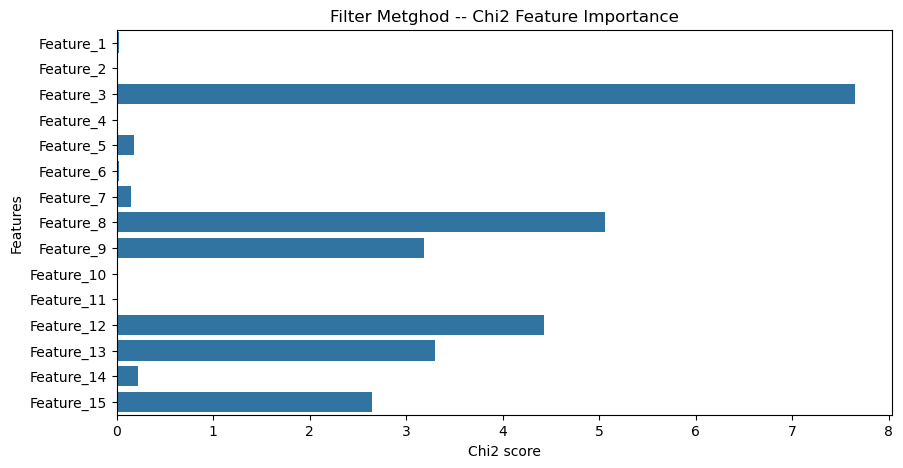

In [12]:
# visualization
plt.figure(figsize=(10,5))
sns.barplot(x=filter_scores, y= feature_names)
plt.title("Filter Metghod -- Chi2 Feature Importance")
plt.xlabel("Chi2 score")
plt.ylabel("Features")
plt.show()

In [ ]:
# wrapper method

In [13]:
model = LogisticRegression(max_iter=1000)

rfe = RFE(estimator=model, n_features_to_select=8)
rfe.fit(X,y)

RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=8)

In [16]:
wrapper_features = np.array(feature_names)[rfe.support_]
ranking = rfe.ranking_
print("\n wrapper Method - Selected Features")
print(wrapper_features)


 wrapper Method - Selected Features
['Feature_3' 'Feature_4' 'Feature_5' 'Feature_8' 'Feature_9' 'Feature_12'
 'Feature_14' 'Feature_15']


In [ ]:
# Embedded Method
select features during model training 
use model coefficient to identify important features

In [17]:
lasso = LassoCV(cv=5, random_state=0)
lasso.fit(X, y)

importance = np.abs(lasso.coef_)
embedded_features = np.array(feature_names)[importance > 0]

print("\n Embedded method - Selected feature")
print(embedded_features)


 Embedded method - Selected feature
['Feature_5' 'Feature_8' 'Feature_9' 'Feature_12' 'Feature_13'
 'Feature_15']
